In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

os.environ.setdefault("DJANGO_SETTINGS_MODULE", "config.settings")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

import django
django.setup()

In [2]:
# Imports y carga de datos.

import pandas as pd
import matplotlib.pyplot as plt

from data_engine.models import BonoExterno, BonoLocal

qs_externos = BonoExterno.objects.filter(vigencia="vigente").values("fecha_vencimiento", "monto", "moneda")
df_externos = pd.DataFrame(qs_externos)
df_externos["monto"] = df_externos["monto"].astype(float)
df_externos["anio_vencimiento"] = pd.to_datetime(df_externos["fecha_vencimiento"]).dt.year

qs_locales = BonoLocal.objects.filter(status="vigente").values("fecha_vencimiento", "monto_colocado", "tipo_instrumento")
df_locales = pd.DataFrame(qs_locales)
df_locales["monto_colocado"] = df_locales["monto_colocado"].astype(float)
df_locales["anio_vencimiento"] = pd.to_datetime(df_locales["fecha_vencimiento"]).dt.year

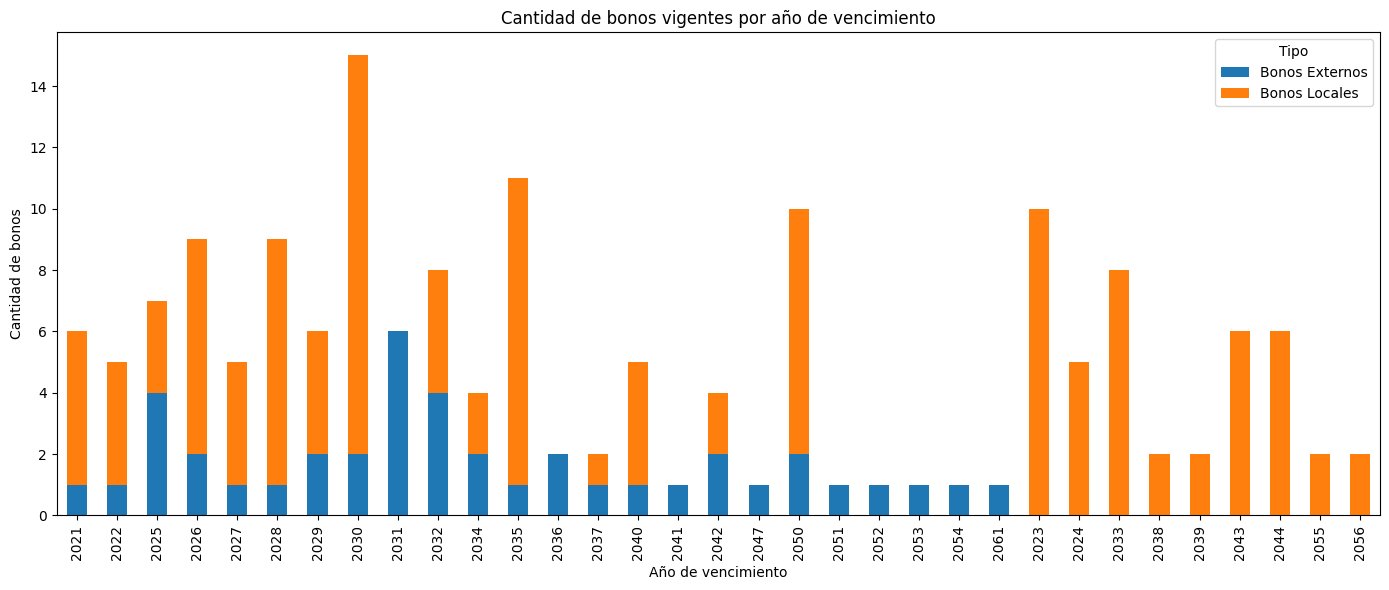

In [3]:
# Conteo combinado por año.

conteo_externos = df_externos.groupby("anio_vencimiento").size().rename("Bonos Externos")
conteo_locales = df_locales.groupby("anio_vencimiento").size().rename("Bonos Locales")

conteo_combinado = pd.concat([conteo_externos, conteo_locales], axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
conteo_combinado.plot.bar(ax=ax, stacked=True)

ax.set_title("Cantidad de bonos vigentes por año de vencimiento")
ax.set_xlabel("Año de vencimiento")
ax.set_ylabel("Cantidad de bonos")
ax.legend(title="Tipo")

plt.tight_layout()
plt.show()

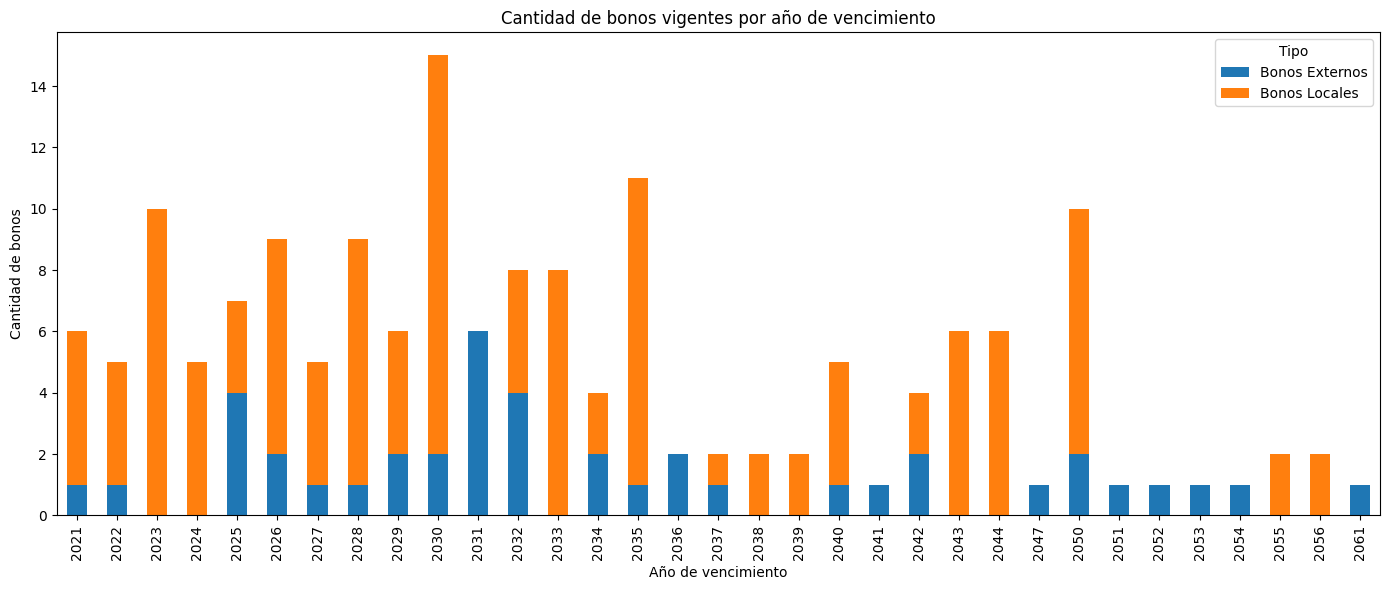

In [4]:
# Ordenando el gráfico de arriba para leer bien los datos.
# Cantidad de bonos por año de vencimiento, ambos juntos.

conteo_combinado = conteo_combinado.sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
conteo_combinado.plot.bar(ax=ax, stacked=True)

ax.set_title("Cantidad de bonos vigentes por año de vencimiento")
ax.set_xlabel("Año de vencimiento")
ax.set_ylabel("Cantidad de bonos")
ax.legend(title="Tipo")

plt.tight_layout()
plt.show()

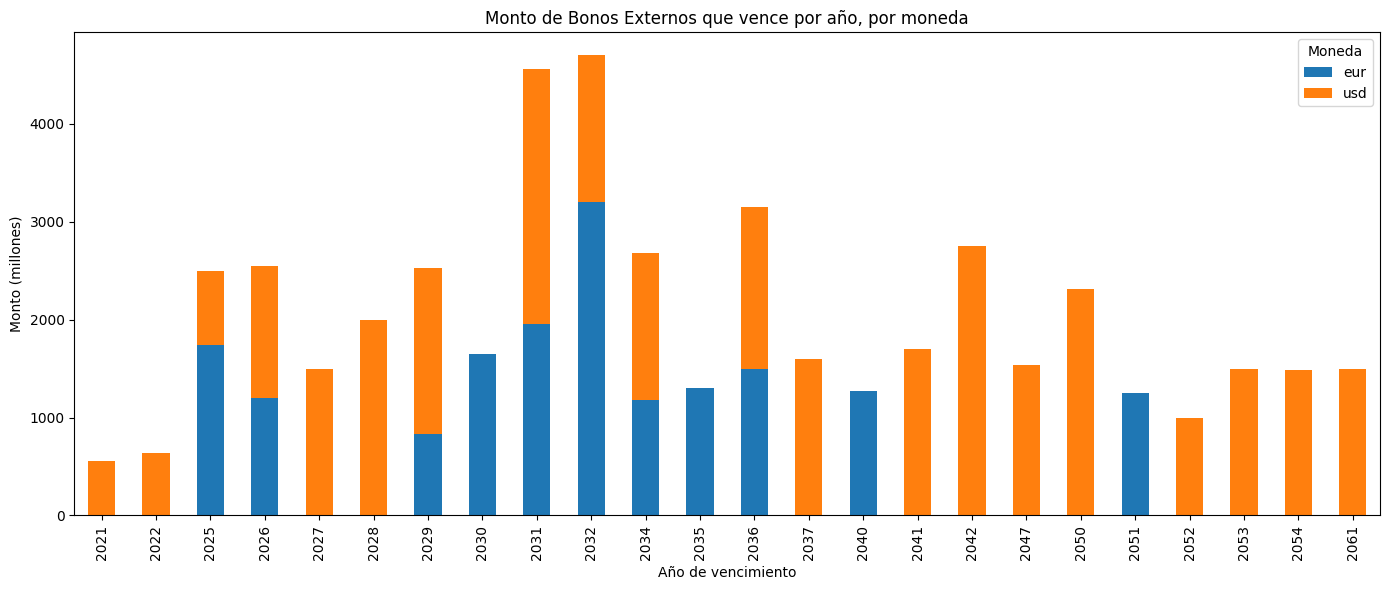

In [5]:
pivot_externos = df_externos.pivot_table(
    index="anio_vencimiento", columns="moneda", values="monto", aggfunc="sum"
).sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
pivot_externos.plot.bar(ax=ax, stacked=True)

ax.set_title("Monto de Bonos Externos que vence por año, por moneda")
ax.set_xlabel("Año de vencimiento")
ax.set_ylabel("Monto (millones)")
ax.legend(title="Moneda")

plt.tight_layout()
plt.show()

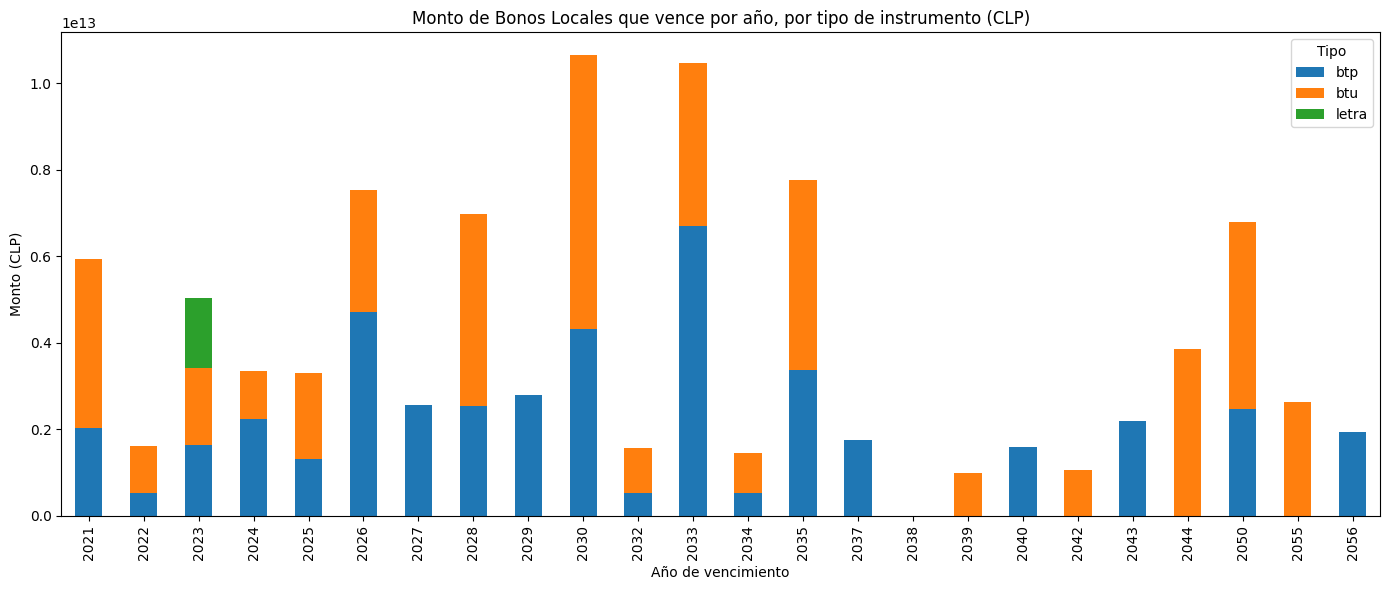

In [6]:
VALOR_UF_APROX = 40885  # CLP, aproximado a sep-2026 — NO es histórico, ver nota anterior

df_locales["monto_clp"] = df_locales.apply(
    lambda fila: fila["monto_colocado"] * VALOR_UF_APROX * 1000 if fila["tipo_instrumento"] == "btu" else fila["monto_colocado"] * 1_000_000,
    axis=1
)

pivot_locales = df_locales.pivot_table(
    index="anio_vencimiento", columns="tipo_instrumento", values="monto_clp", aggfunc="sum"
).sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
pivot_locales.plot.bar(ax=ax, stacked=True)

ax.set_title("Monto de Bonos Locales que vence por año, por tipo de instrumento (CLP)")
ax.set_xlabel("Año de vencimiento")
ax.set_ylabel("Monto (CLP)")
ax.legend(title="Tipo")

plt.tight_layout()
plt.show()

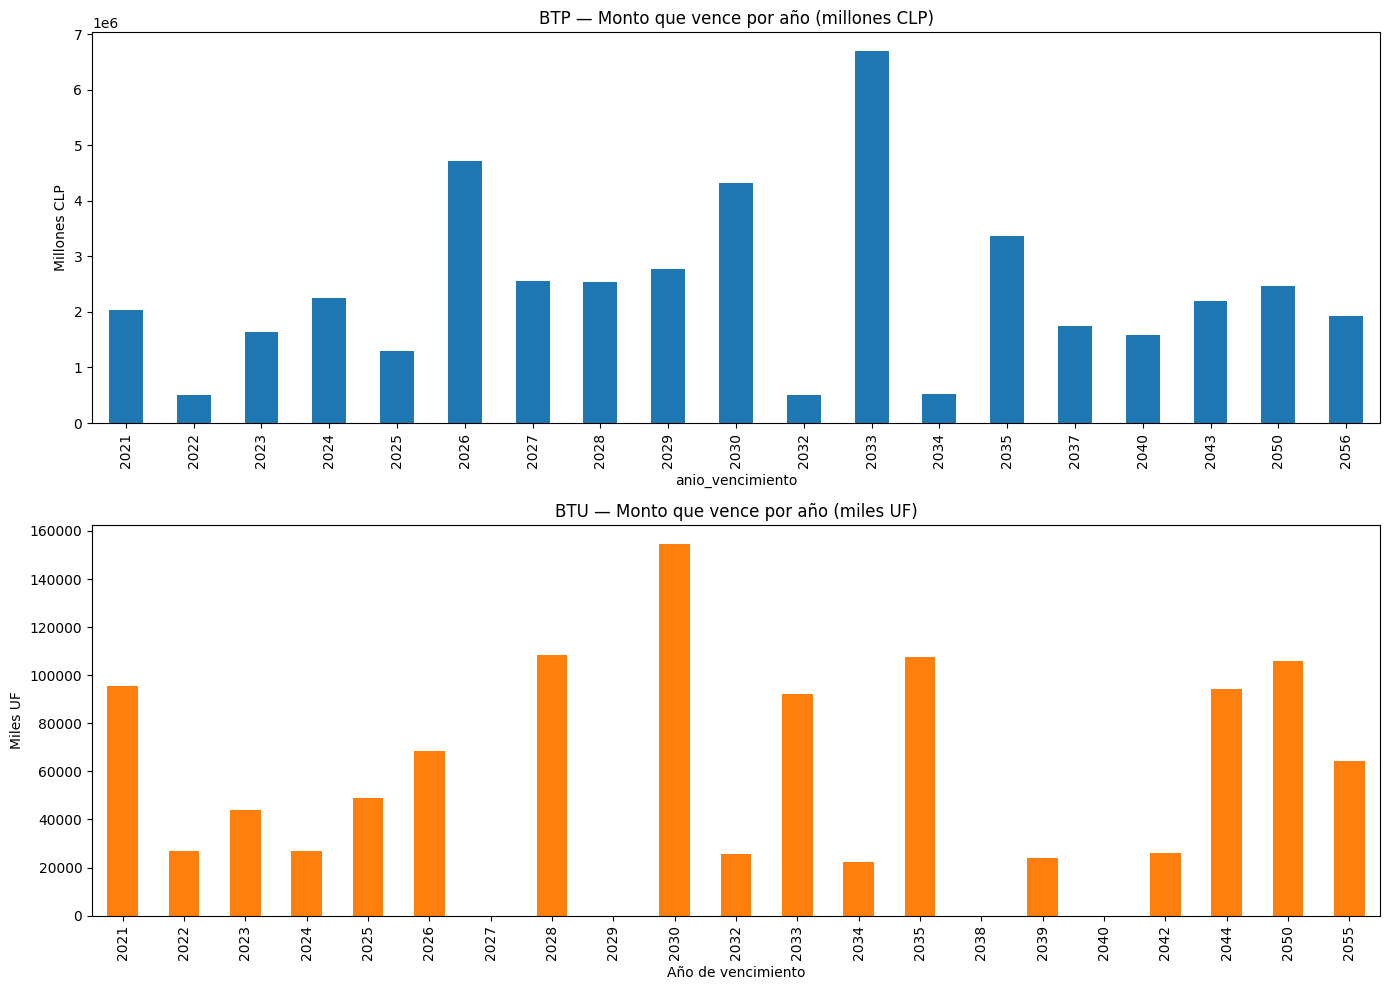

In [7]:
pivot_btp = df_locales[df_locales["tipo_instrumento"] == "btp"].pivot_table(
    index="anio_vencimiento", values="monto_colocado", aggfunc="sum"
).sort_index()
pivot_btu = df_locales[df_locales["tipo_instrumento"] == "btu"].pivot_table(
    index="anio_vencimiento", values="monto_colocado", aggfunc="sum"
).sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

pivot_btp.plot.bar(ax=axes[0], legend=False, color="#1f77b4")
axes[0].set_title("BTP — Monto que vence por año (millones CLP)")
axes[0].set_ylabel("Millones CLP")

pivot_btu.plot.bar(ax=axes[1], legend=False, color="#ff7f0e")
axes[1].set_title("BTU — Monto que vence por año (miles UF)")
axes[1].set_ylabel("Miles UF")
axes[1].set_xlabel("Año de vencimiento")

plt.tight_layout()
plt.show()

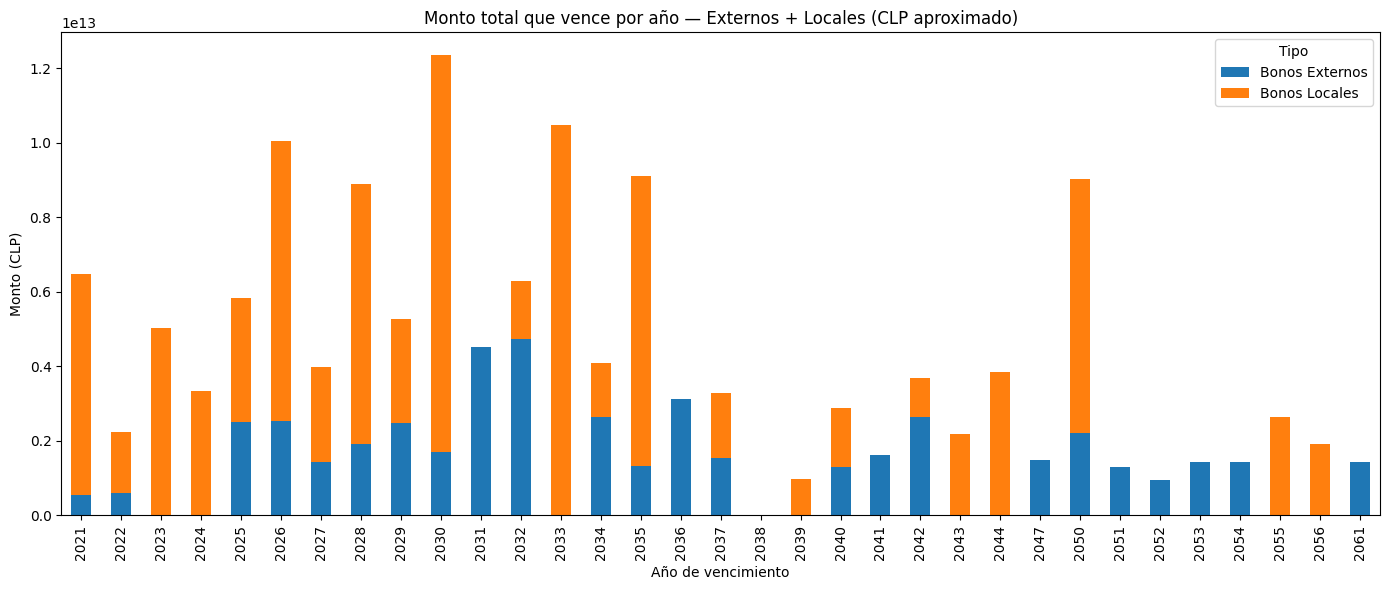

In [8]:
# Gráfico combinado de bonos externos y locales convertidos a moneda local, valores aproximados.

TIPO_CAMBIO_APROX = {
    "usd": 959.5,   # CLP, 18-sep-2026
    "eur": 1030.0,  # CLP, aproximado — no se encontró cotización tan reciente como la del dólar
}
VALOR_UF_APROX = 40885  # CLP, sep-2026 (ya usado en el gráfico de BonoLocal)

# Bonos Externos -> CLP
df_externos["monto_clp"] = df_externos.apply(
    lambda fila: fila["monto"] * TIPO_CAMBIO_APROX[fila["moneda"]] * 1_000_000,
    axis=1
)

# Bonos Locales -> CLP (ya tenías esta lógica, la repito para que quede todo junto)
df_locales["monto_clp"] = df_locales.apply(
    lambda fila: fila["monto_colocado"] * VALOR_UF_APROX * 1000 if fila["tipo_instrumento"] == "btu" else fila["monto_colocado"] * 1_000_000,
    axis=1
)

# Combinar ambos en una sola serie por año
serie_externos = df_externos.groupby("anio_vencimiento")["monto_clp"].sum().rename("Bonos Externos")
serie_locales = df_locales.groupby("anio_vencimiento")["monto_clp"].sum().rename("Bonos Locales")

combinado_clp = pd.concat([serie_externos, serie_locales], axis=1).fillna(0).sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
combinado_clp.plot.bar(ax=ax, stacked=True)

ax.set_title("Monto total que vence por año — Externos + Locales (CLP aproximado)")
ax.set_xlabel("Año de vencimiento")
ax.set_ylabel("Monto (CLP)")
ax.legend(title="Tipo")

plt.tight_layout()
plt.show()

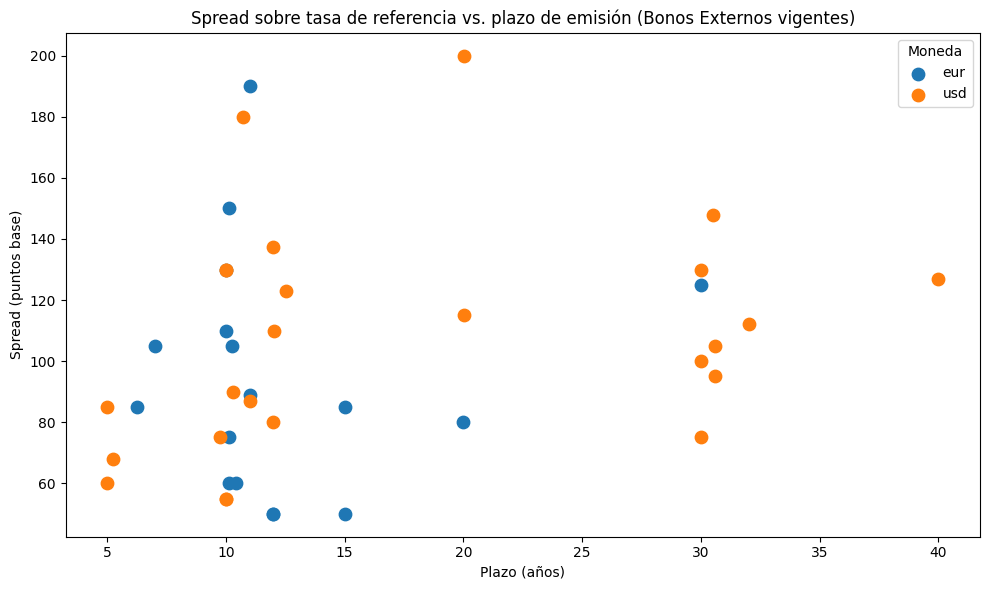

In [9]:
# Revisando el spread de los bonos externos.

qs_externos_spread = BonoExterno.objects.filter(vigencia="vigente").values(
    "nombre_bono", "fecha_emision", "fecha_vencimiento", "spread_caratula", "moneda", "tasa_caratula_fija"
)
df_spread = pd.DataFrame(qs_externos_spread)
df_spread["plazo_anios"] = (
    pd.to_datetime(df_spread["fecha_vencimiento"]) - pd.to_datetime(df_spread["fecha_emision"])
).dt.days / 365.25
df_spread["spread_caratula"] = df_spread["spread_caratula"].astype(float)

fig, ax = plt.subplots(figsize=(10, 6))
for moneda, grupo in df_spread.groupby("moneda"):
    ax.scatter(grupo["plazo_anios"], grupo["spread_caratula"], label=moneda, s=80)

ax.set_title("Spread sobre tasa de referencia vs. plazo de emisión (Bonos Externos vigentes)")
ax.set_xlabel("Plazo (años)")
ax.set_ylabel("Spread (puntos base)")
ax.legend(title="Moneda")

plt.tight_layout()
plt.show()

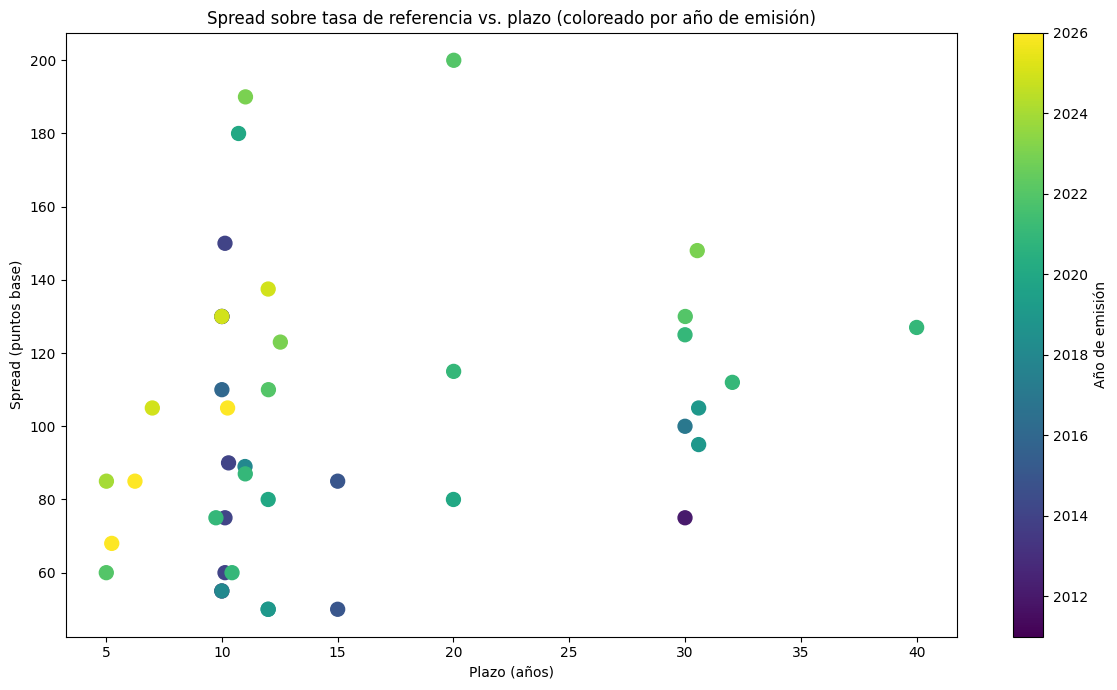

In [11]:
# Volvemos a revisar los bonos externos pero ahora agregamos el año de emisión ya que el spread parece relacionarse con eso más que con el plazo

fig, ax = plt.subplots(figsize=(12, 7))

df_spread["anio_emision"] = pd.to_datetime(df_spread["fecha_emision"]).dt.year

scatter = ax.scatter(
    df_spread["plazo_anios"], df_spread["spread_caratula"],
    c=df_spread["anio_emision"], cmap="viridis", s=100
)

ax.set_title("Spread sobre tasa de referencia vs. plazo (coloreado por año de emisión)")
ax.set_xlabel("Plazo (años)")
ax.set_ylabel("Spread (puntos base)")

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Año de emisión")

plt.tight_layout()
plt.show()

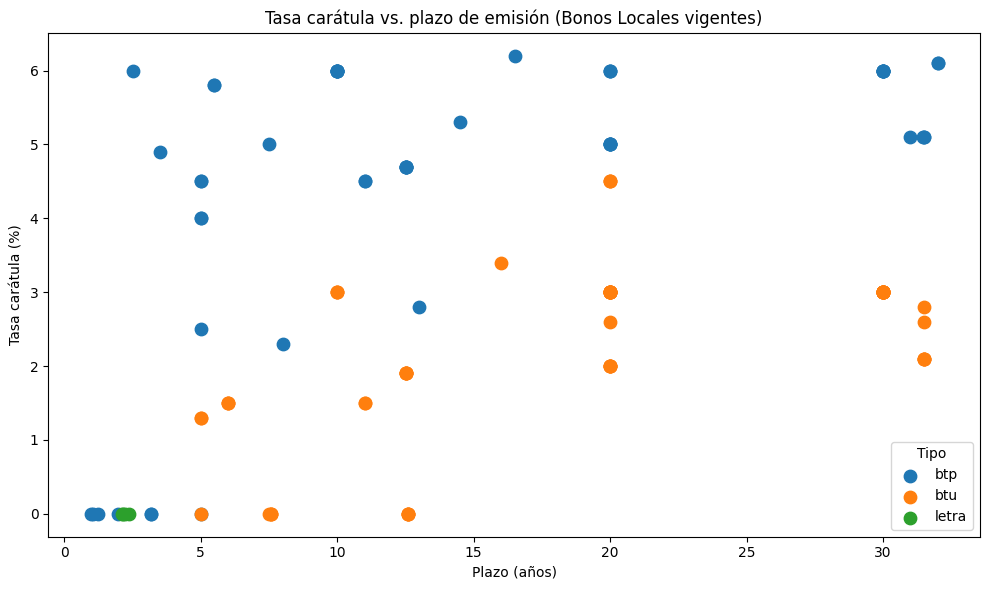

In [10]:
# Revisando la tasa carátula (lo que paga el bono cuando fue emitido) de los bonos locales.

qs_locales_tasa = BonoLocal.objects.filter(status="vigente").values(
    "nombre_bono", "fecha_emision", "fecha_vencimiento", "tasa_caratula", "tipo_instrumento"
)
df_tasa_local = pd.DataFrame(qs_locales_tasa)
df_tasa_local["plazo_anios"] = (
    pd.to_datetime(df_tasa_local["fecha_vencimiento"]) - pd.to_datetime(df_tasa_local["fecha_emision"])
).dt.days / 365.25
df_tasa_local["tasa_caratula"] = df_tasa_local["tasa_caratula"].astype(float)

fig, ax = plt.subplots(figsize=(10, 6))
for tipo, grupo in df_tasa_local.groupby("tipo_instrumento"):
    ax.scatter(grupo["plazo_anios"], grupo["tasa_caratula"], label=tipo, s=80)

ax.set_title("Tasa carátula vs. plazo de emisión (Bonos Locales vigentes)")
ax.set_xlabel("Plazo (años)")
ax.set_ylabel("Tasa carátula (%)")
ax.legend(title="Tipo")

plt.tight_layout()
plt.show()